In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

df = pd.read_csv('data/phone_usage.csv')
df

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   str    
 1   user_id                  7500 non-null   str    
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   str    
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   str    
 13  academic_work_impact     7500 non-null   str    
 14  addiction_level          6681 non-n

In [3]:
df.isnull().sum()

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

In [4]:
df['addiction_level'].unique()

<ArrowStringArray>
[nan, 'Mild', 'Moderate', 'Severe']
Length: 4, dtype: str

In [5]:
df['addiction_level'] = df['addiction_level'].fillna('None')

In [6]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [7]:
df['gender'].unique()

<ArrowStringArray>
['Male', 'Other', 'Female']
Length: 3, dtype: str

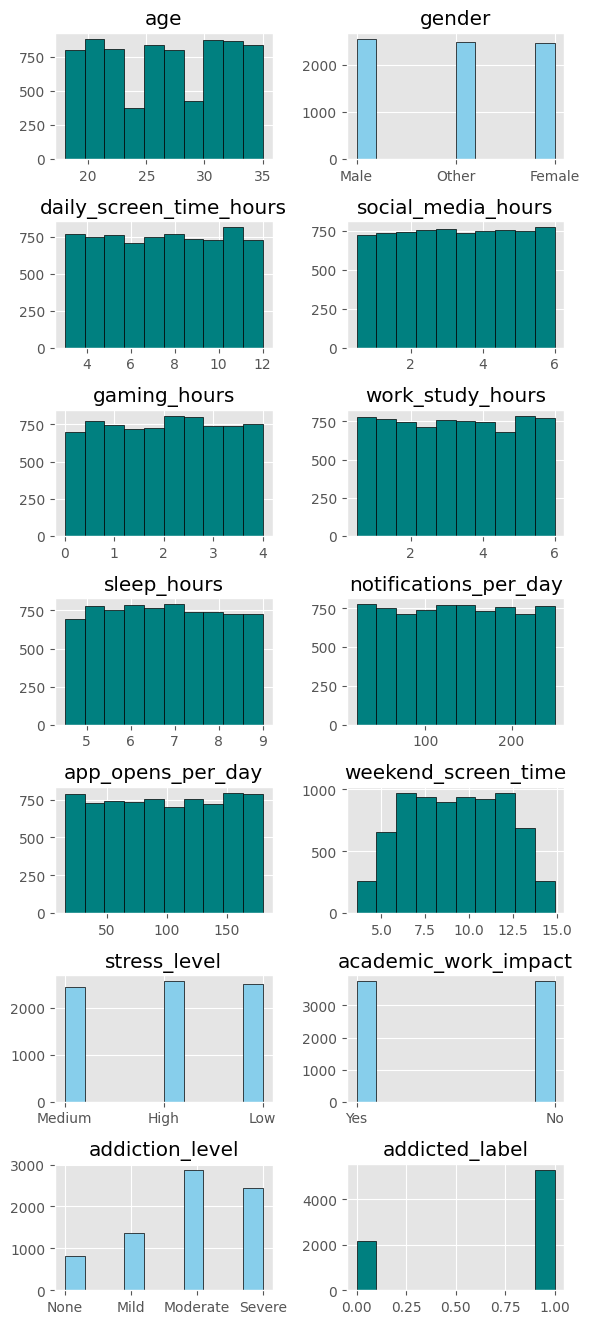

In [28]:
columns = df.columns

c = 2
r = int(len(columns) // 2)

plt.figure(figsize=(6, 15))

for count, col in enumerate(columns):
    if col not in ['transaction_id', 'user_id']:
        plt.subplot(r, c, count + 1)
        if df[col].dtype in ['str']:
            df[col].hist(edgecolor= 'black', color = 'skyblue')
        else:
            df[col].hist(edgecolor= 'black', color = 'teal')
        plt.title(col)

plt.tight_layout()
plt.show()


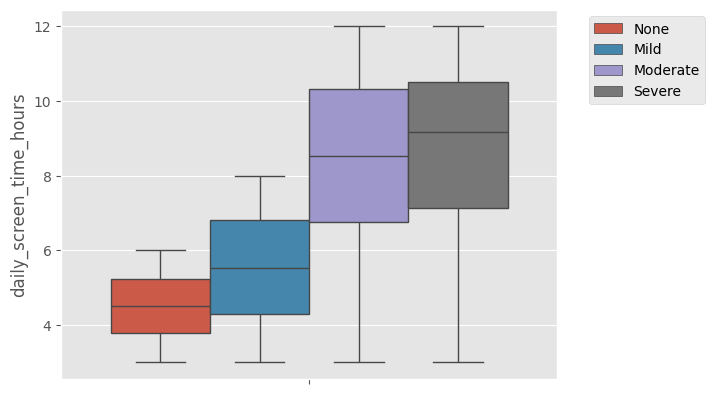

In [25]:
sns.boxplot(df, y = 'daily_screen_time_hours', hue= 'addiction_level')
plt.legend(bbox_to_anchor = (1.05, 1))
plt.show()

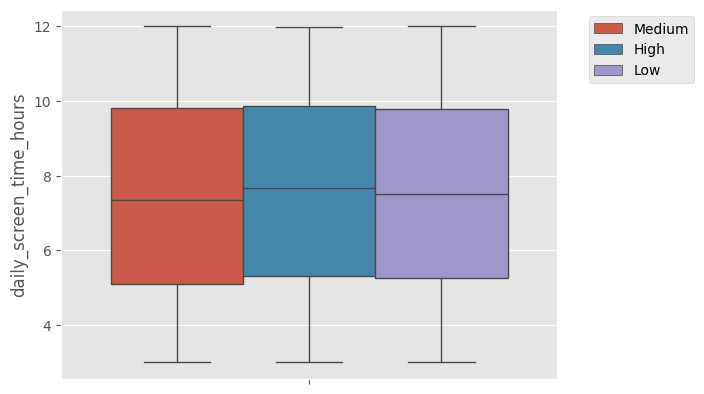

In [26]:
sns.boxplot(df, y = 'daily_screen_time_hours', hue= 'stress_level')
plt.legend(bbox_to_anchor = (1.05, 1))
plt.show()

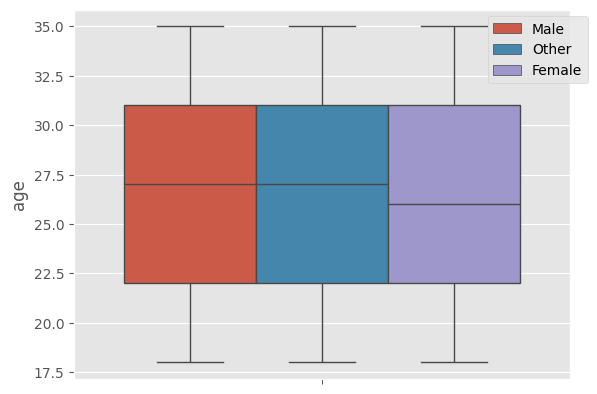

In [27]:
sns.boxplot(df, y = 'age', hue= 'gender')
plt.legend(bbox_to_anchor = (1.05, 1))
plt.show()

Categorized by gender


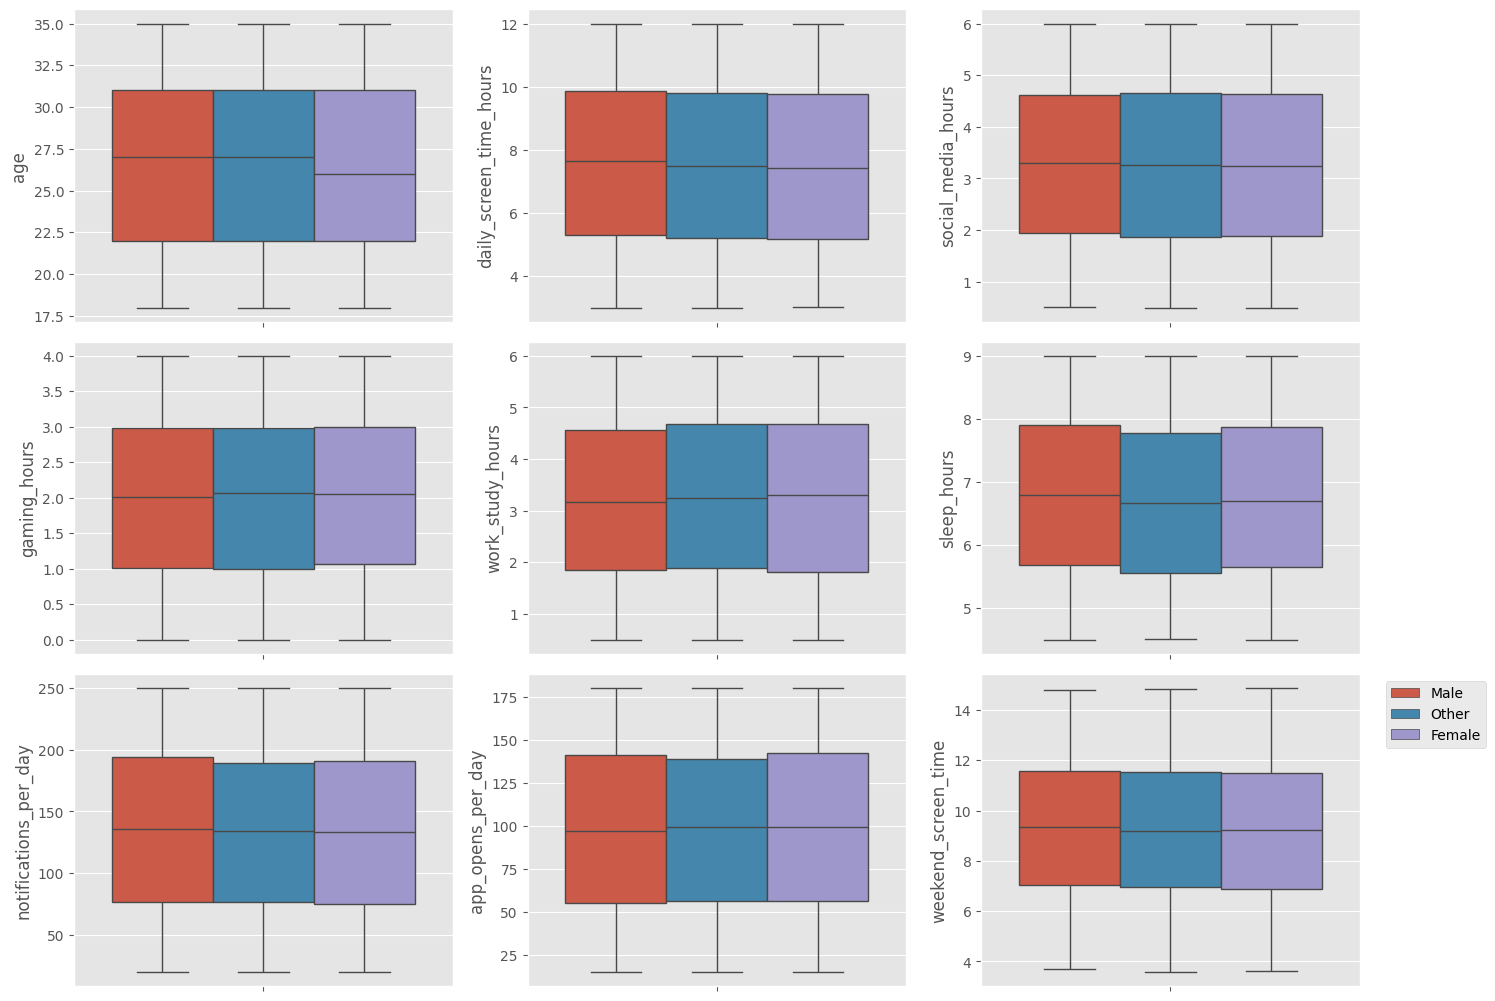

--------------------------------------------------
Categorized by stress_level


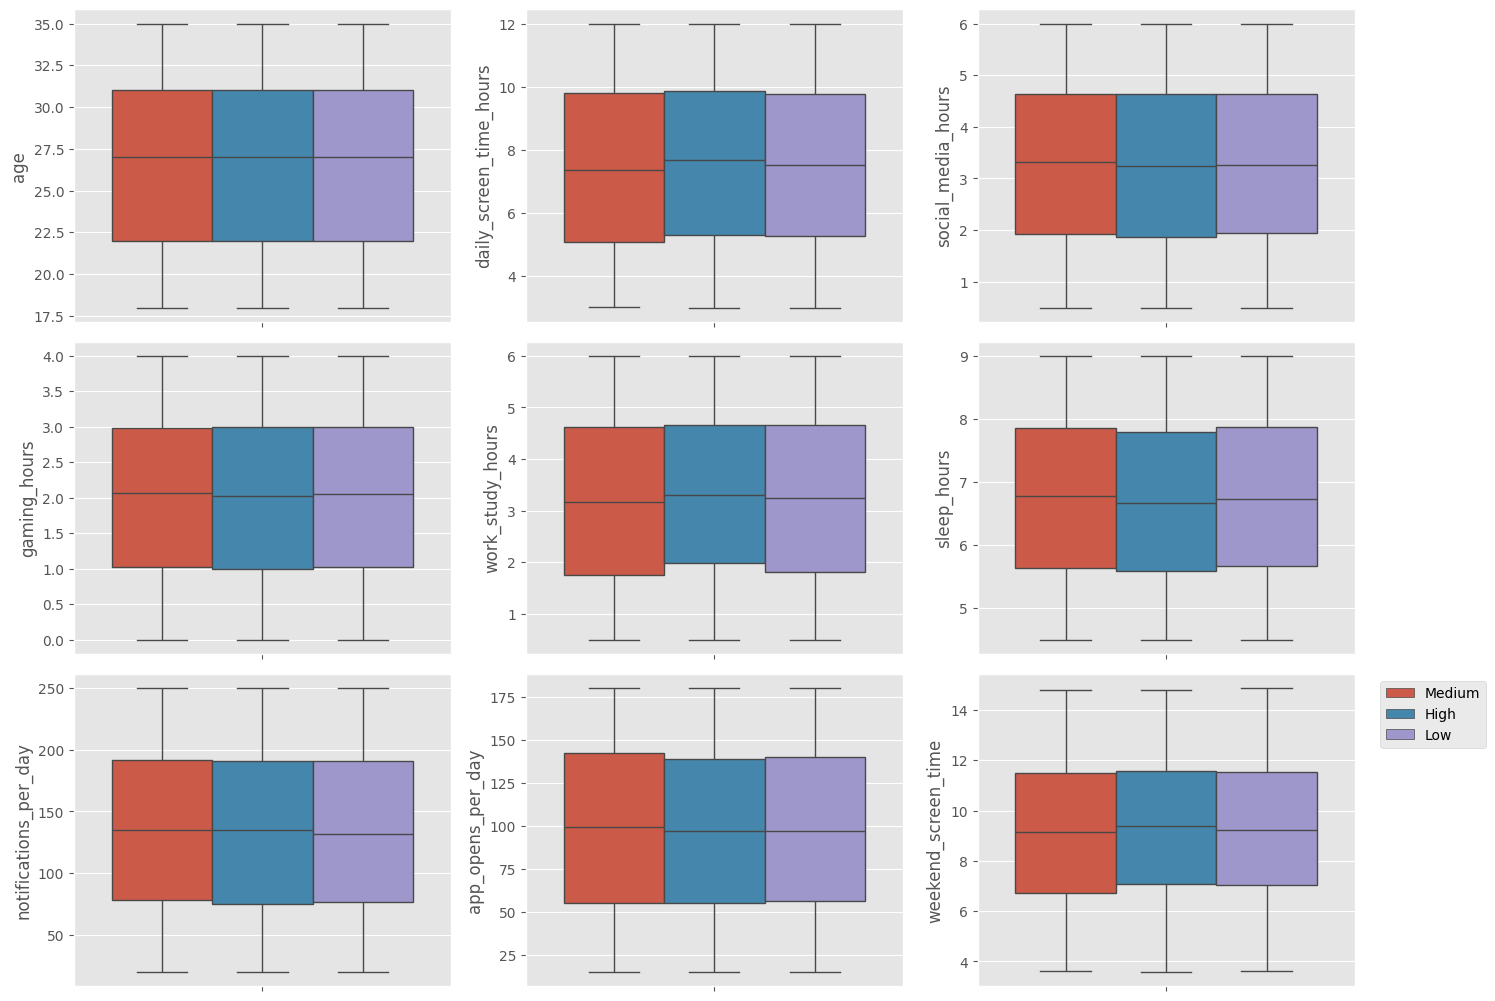

--------------------------------------------------
Categorized by academic_work_impact


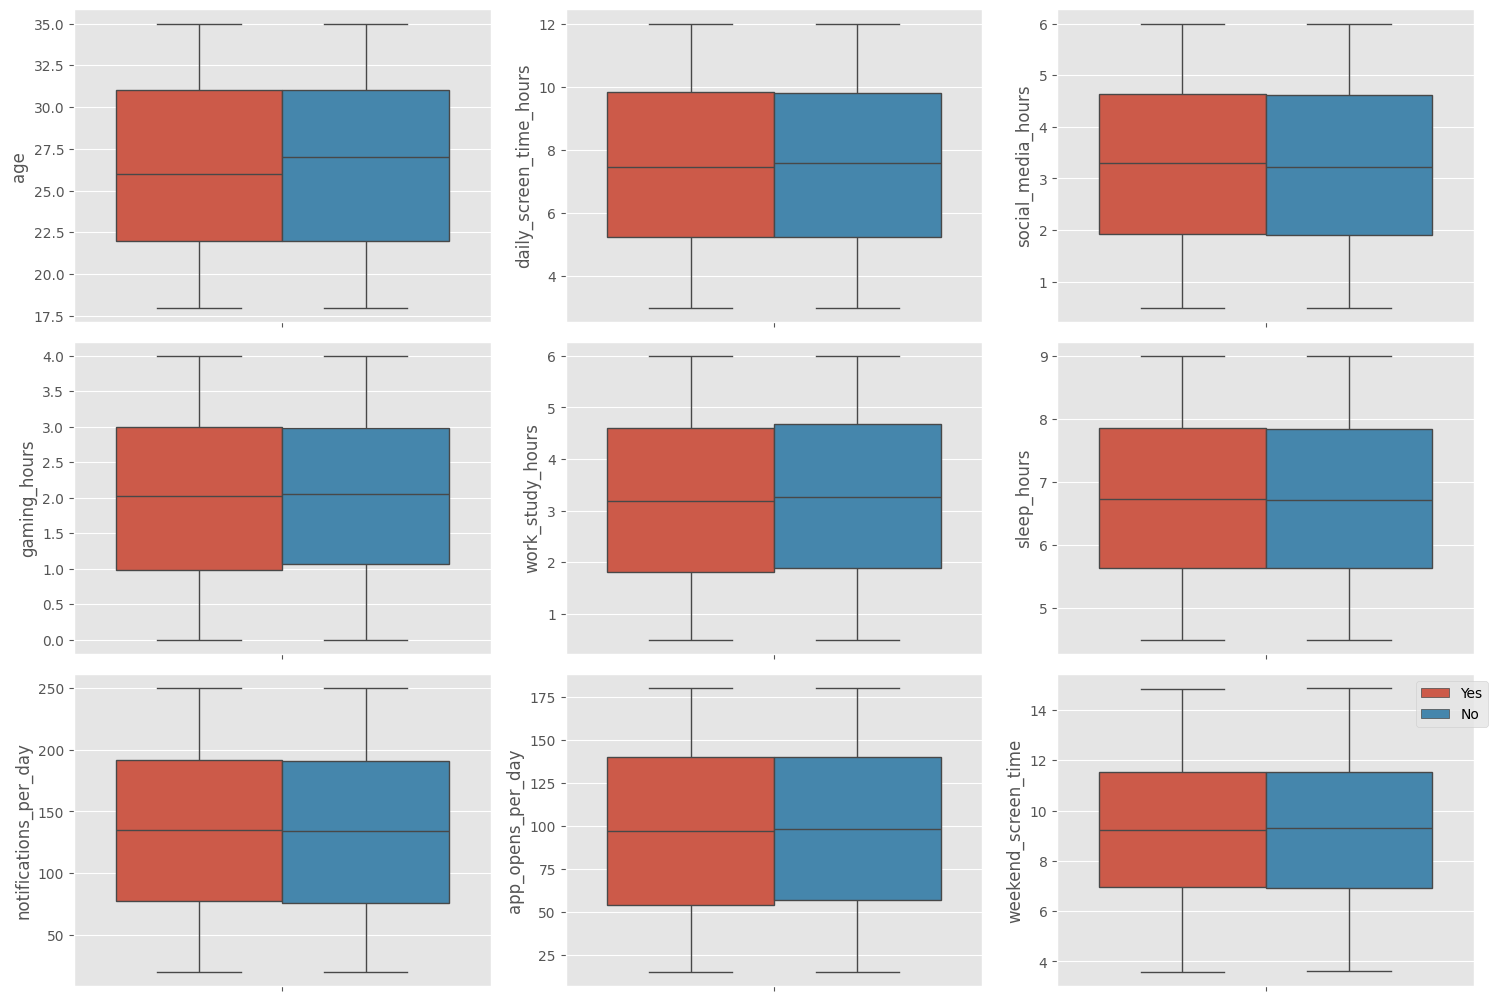

--------------------------------------------------
Categorized by addiction_level


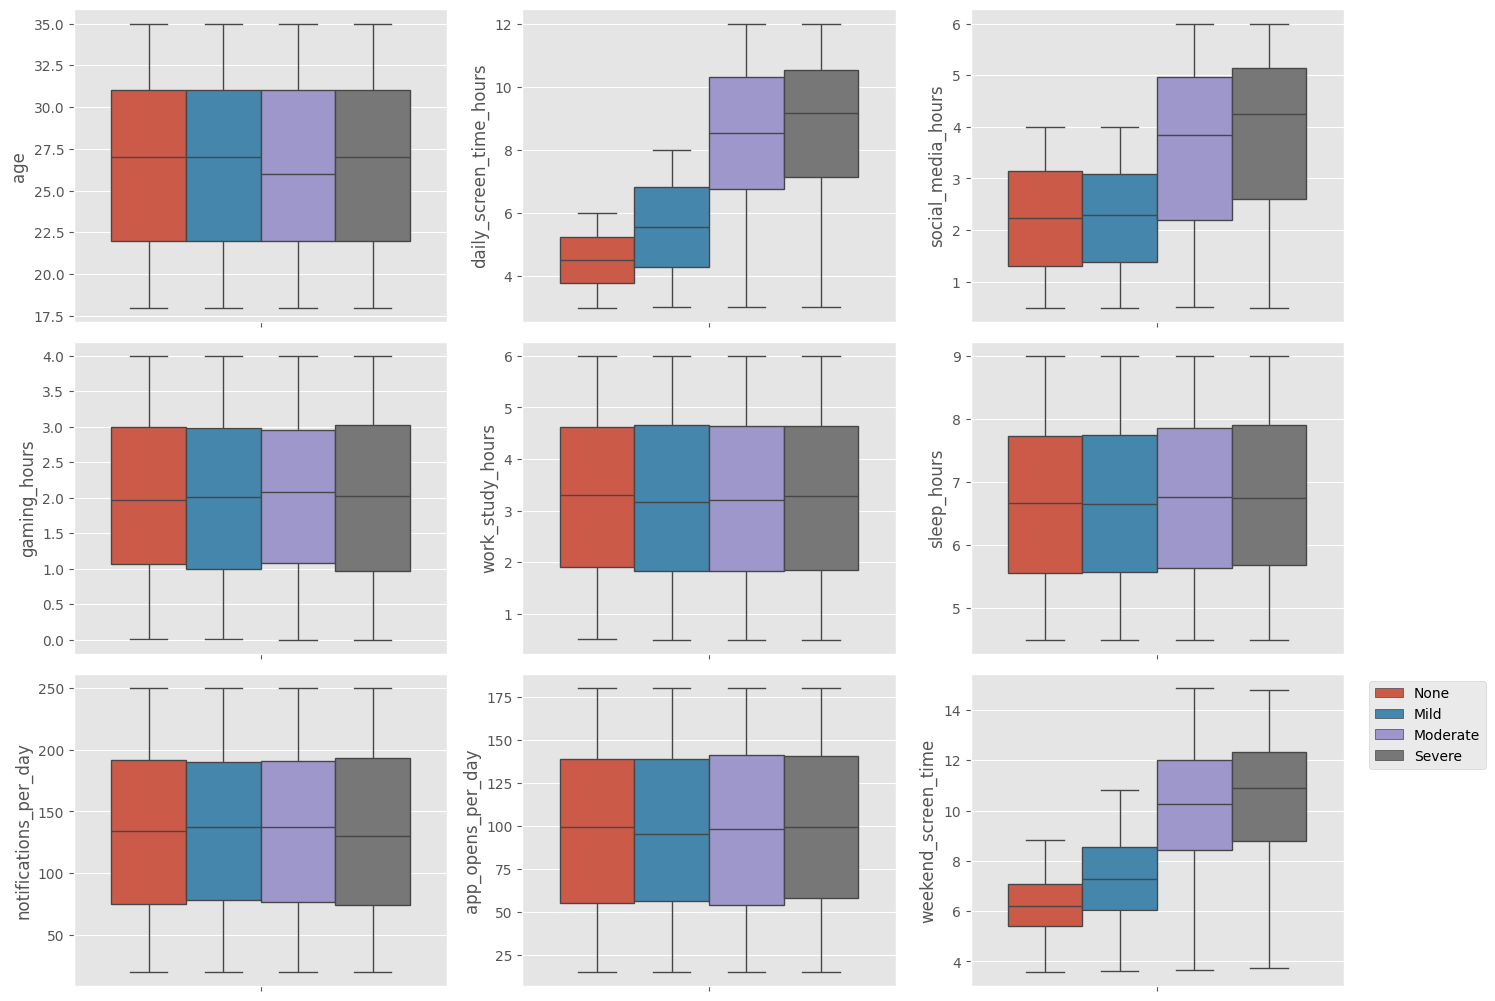

--------------------------------------------------
Categorized by addicted_label


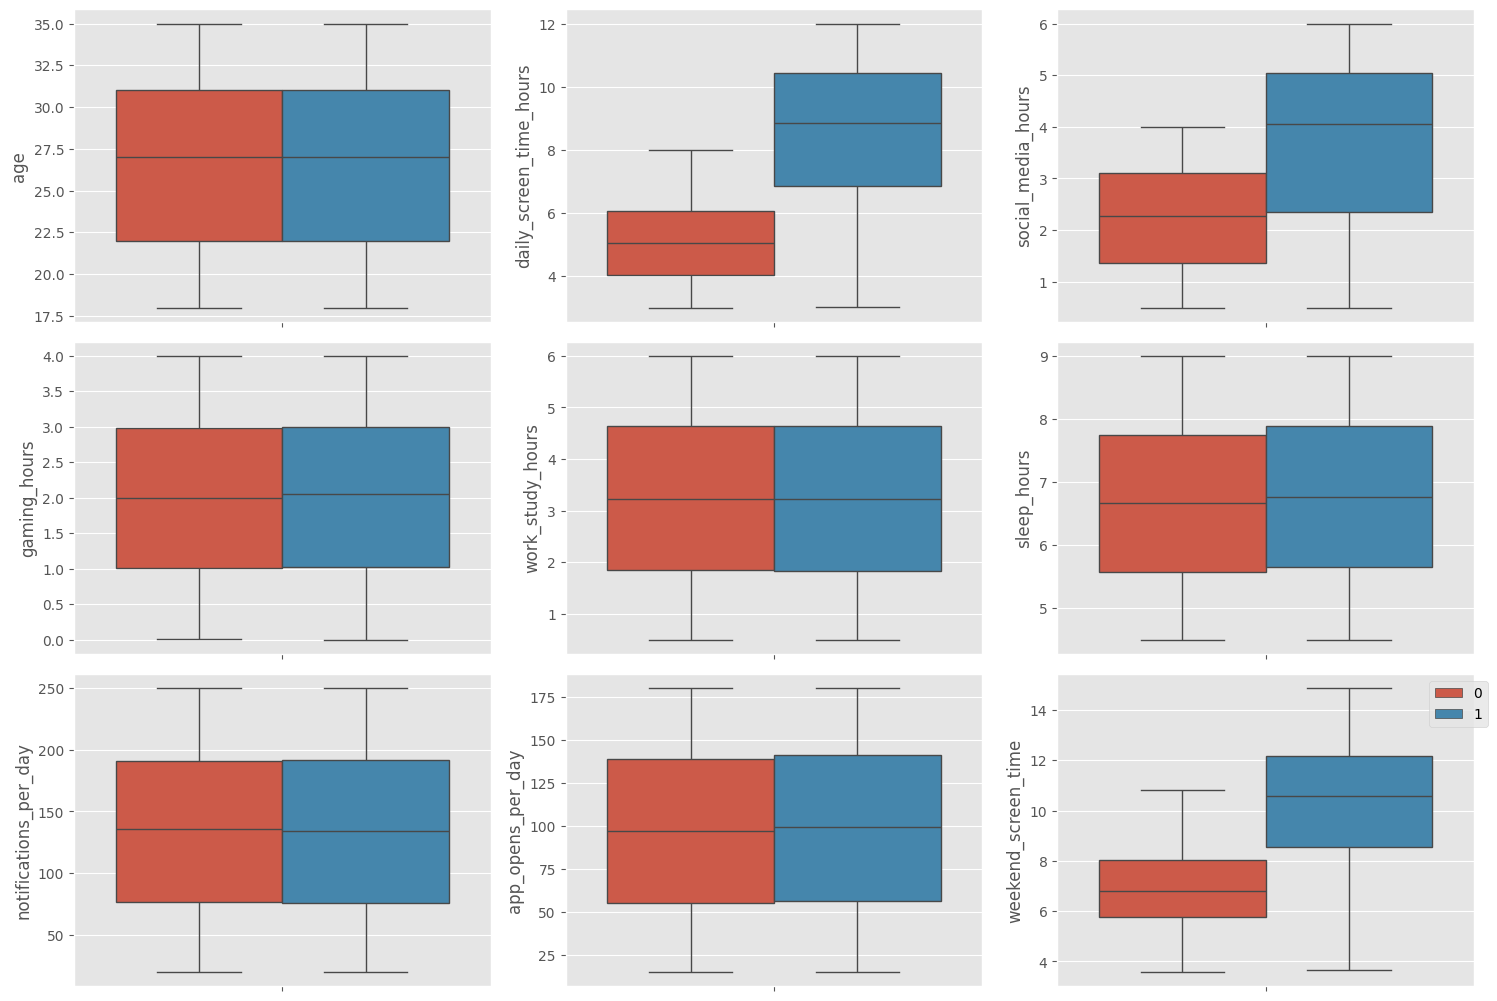

--------------------------------------------------


In [42]:

cat_col = ['gender', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label']

num_col = [c for c in df.select_dtypes(exclude=['str']).columns if c not in ['addicted_label']]

for category in cat_col:
    print(f'Categorized by {category}')
    plt.figure(figsize = (15, 30))
    row = len(num_col)
    col = 3

    for count, ele in enumerate(num_col):
        plt.subplot(row, col, count + 1)
        sns.boxplot(df, y = ele, hue= category)
        plt.legend([], frameon=False)
    
    
    plt.legend(bbox_to_anchor = (1.05, 1))
    
    plt.tight_layout()
    plt.show()
    print('-' * 50)

So the addiction is mostly relates to `social_media_hours`

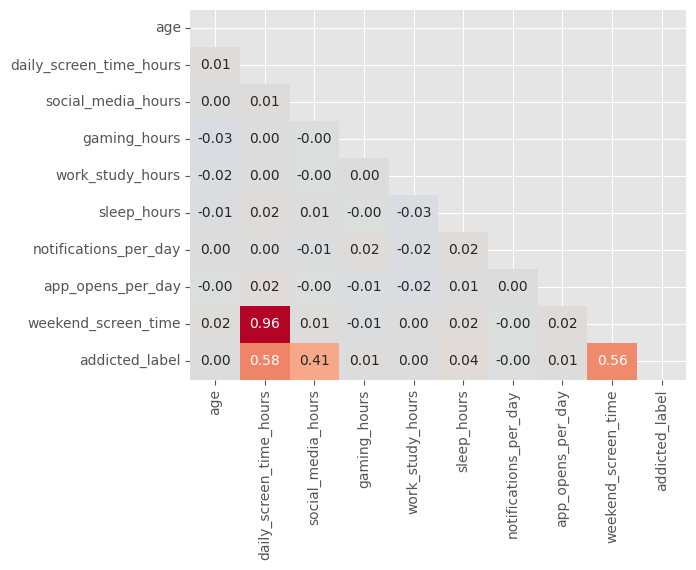

In [43]:
corr_col = df.select_dtypes(exclude='str').columns

matrix = df[corr_col].corr()

mask = np.triu(np.ones_like(matrix, dtype= bool))

sns.heatmap(matrix, mask = mask, center =0 ,cmap ='coolwarm',
            annot = True, fmt = '.2f',cbar = False)

plt.show()

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier

col_to_use = ['weekend_screen_time', 'daily_screen_time_hours', 'social_media_hours']
target = ['addicted_label']

X = df[col_to_use].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 8, stratify= y)

print(X_train.shape, X_test.shape)





(5625, 3) (1875, 3)


In [62]:
pos = (y_train[target].values == 1).sum()
neg = (y_train[target].values == 0).sum()

ratio = float(neg / pos)
print(ratio)

0.4129615674453655


In [ ]:

models = {
    'base' : Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight= 'balanced',
        max_iter= 500
    ))]),
    'xgb' : XGBClassifier(
        n_estimators = 200,
        random_state = 8,
        scale_pos_weight = ratio
    )
}


Model base
              precision    recall  f1-score   support

           0       0.73      0.87      0.80       548
           1       0.94      0.87      0.90      1327

    accuracy                           0.87      1875
   macro avg       0.84      0.87      0.85      1875
weighted avg       0.88      0.87      0.87      1875


------------------------------------------------------

Model xgb
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       548
           1       0.96      0.96      0.96      1327

    accuracy                           0.94      1875
   macro avg       0.92      0.92      0.92      1875
weighted avg       0.94      0.94      0.94      1875


------------------------------------------------------



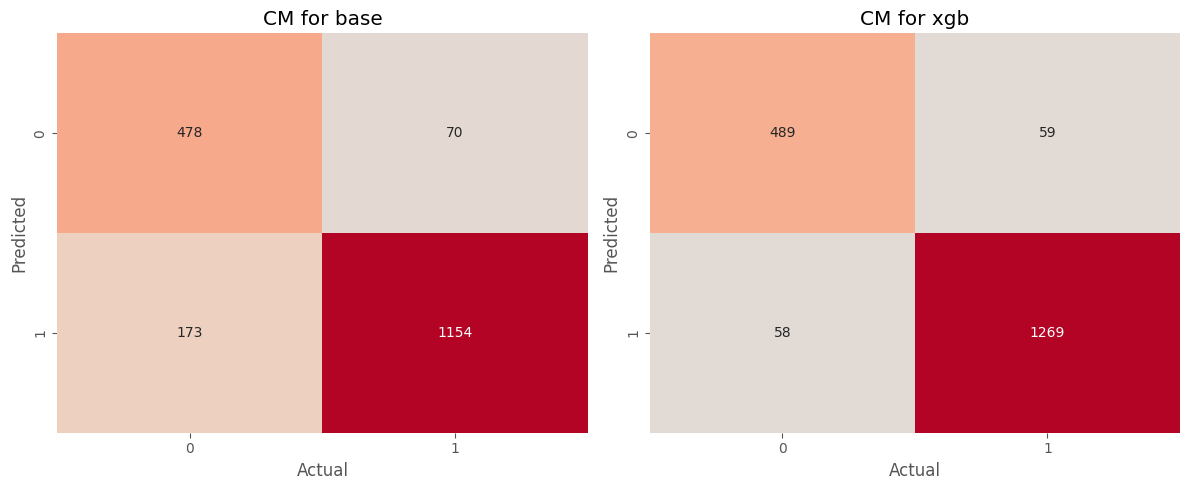

In [67]:
from sklearn.metrics import classification_report, confusion_matrix

plt.figure(figsize= (12, 5))

for count, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train.values.ravel())

    y_pred = model.predict(X_test)

    print(f'Model {name}')
    print(classification_report(y_true= y_test, y_pred= y_pred))
    print('\n------------------------------------------------------\n')
    plt.subplot(1, 2, count + 1)
    cm = confusion_matrix(y_true= y_test, y_pred= y_pred)
    sns.heatmap(cm, cmap = 'coolwarm', center = 0, cbar = False, 
                annot = True, fmt = 'd')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'CM for {name}')

plt.tight_layout()
plt.show()